In [36]:
import importlib
import merge_plot
import obi_signal_test
import calibrate_microprice
import pandas as pd
import numpy as np
import glob
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from pathlib import Path
from datetime import timezone

## Configuration
Edit the constants below to tune OBI depth/decay and signal-test parameters.
Re-run from here after any change — cells below consume these values.

In [ ]:
# ── OBI parameters (mirrors merge_plot.OBI_DEPTH / OBI_DECAY) ───────────────
OBI_DEPTH = 5      # price levels per side (1 = top-of-book, 10 = deep)
OBI_DECAY = 0.2    # exponential down-weighting; 0.0 = flat (original)

# ── Signal-test parameters ────────────────────────────────────────────────────
HORIZON     = 1     # forward look window in seconds
SIGNAL_WIN  = 0.25  # backward window for OBI delta in seconds
THRESHOLD   = 0.40  # minimum |d_obi| to fire a signal
MIN_TICK    = 0.01  # minimum mid move ($) to count as a hit
COOLDOWN    = 0.5   # seconds to suppress re-firing after a signal

# ── Data paths ────────────────────────────────────────────────────────────────
DATA_DIR    = '../../bigdata'          # all CSVs live here (relative to analysis/)
GSTAR_PATH  = 'g_star.json'      # calibration file (in analysis/)

# ── Single session to explore ─────────────────────────────────────────────────
TICKER = 'KXBTC15M-26MAR162145-45'

# Push OBI params into merge_plot so parse_kalshi uses them
merge_plot.OBI_DEPTH = OBI_DEPTH
merge_plot.OBI_DECAY = OBI_DECAY
print(f'OBI_DEPTH={OBI_DEPTH}  OBI_DECAY={OBI_DECAY}')
print(f'Horizon={HORIZON}s  SignalWin={SIGNAL_WIN}s  Threshold={THRESHOLD}  MinTick={MIN_TICK}')
print(f'Data dir : {DATA_DIR}')
print(f'G* path  : {GSTAR_PATH}')

OBI_DEPTH=5  OBI_DECAY=0.2
Horizon=1s  SignalWin=0.25s  Threshold=0.4  MinTick=0.01
Data dir : ../../bigdata
G* path  : g_star.json


## Single Session — Load, Merge, Plot

In [38]:
importlib.reload(merge_plot)

kalshi_df, _ = merge_plot.parse_kalshi(f'{DATA_DIR}/{TICKER}.csv')
market_open  = kalshi_df.index[0]
market_close = kalshi_df.index[-1]

btc_df = merge_plot.parse_btc(f'{DATA_DIR}/BTC-{TICKER}.csv',
                               market_open  - merge_plot.BTC_BUFFER,
                               market_close + merge_plot.BTC_BUFFER)
merged = merge_plot.asof_join(kalshi_df, btc_df)
print(merged[['mid', 'spread', 'obi', 'obi1', 'obi3', 'obi5', 'obi10', 'btc_mid']].describe().round(4))

merged['d_obi']    = merged['obi'].diff()
merged['d_btc']    = merged['btc_mid'].diff()
merged['d_kalshi'] = merged['mid'].diff()

print(merged[['d_btc', 'd_obi', 'd_kalshi']].corr())

[Kalshi]  79,946 deltas  01:30:00 → 01:45:00 UTC  ticker=KXBTC15M-26MAR162145-45
[BTC]     5,724 ticker updates  01:29:55 → 01:45:05 UTC  clipped to [01:29:55, 01:45:05]
[Join]    79,946 merged rows
              mid      spread         obi        obi1        obi3        obi5  \
count  76505.0000  76505.0000  79946.0000  79946.0000  79946.0000  79946.0000   
mean       0.3260      0.0146     -0.1341     -0.0514     -0.1195     -0.1664   
std        0.1523      0.0113      0.4761      0.7177      0.4605      0.4857   
min        0.0150      0.0100     -1.0000     -1.0000     -1.0000     -1.0000   
25%        0.1750      0.0100     -0.5092     -0.7814     -0.4938     -0.5291   
50%        0.3650      0.0100     -0.2166     -0.1026     -0.1384     -0.2468   
75%        0.4050      0.0200      0.2608      0.6803      0.2364      0.1770   
max        0.6450      0.9800      1.0000      1.0000      1.0000      1.0000   

            obi10     btc_mid  
count  79946.0000  79946.0000  
mean   

In [39]:
merge_plot.plot(merged, TICKER, market_open, market_close,
                f'chart_{TICKER}_depth{OBI_DEPTH}_decay{OBI_DECAY}.png')

[Chart]   → chart_KXBTC15M-26MAR162145-45_depth5_decay0.2.png


In [40]:
display(merged.head(10))

,seq,side,price,delta,mid,bid,ask,spread,obi,obi1,...,obi10,yes_depth,no_depth,microprice,btc_bid,btc_ask,btc_mid,d_obi,d_btc,d_kalshi
ts,,,,,,,,,,,,,,,,,,,,,
2026-03-17 01:30:00.002043+00:00,2,yes,0.01,400.0,NaN,0.01,NaN,NaN,1.000000,1.000000,...,1.000000,400.0,0.0,None,75935.01,75937.4,75936.205,NaN,NaN,NaN
2026-03-17 01:30:00.004305+00:00,3,no,0.01,500.0,0.500,0.01,0.99,0.98,-0.111111,-0.111111,...,-0.111111,400.0,500.0,None,75935.01,75937.4,75936.205,-1.111111,0.0,NaN
2026-03-17 01:30:00.004332+00:00,4,no,0.01,6000.0,0.500,0.01,0.99,0.98,-0.884058,-0.884058,...,-0.884058,400.0,6500.0,None,75935.01,75937.4,75936.205,-0.772947,0.0,0.000
2026-03-17 01:30:00.005584+00:00,5,yes,0.01,6000.0,0.500,0.01,0.99,0.98,-0.007752,-0.007752,...,-0.007752,6400.0,6500.0,None,75935.01,75937.4,75936.205,0.876306,0.0,0.000
2026-03-17 01:30:00.013014+00:00,6,no,0.01,1.0,0.500,0.01,0.99,0.98,-0.007829,-0.007829,...,-0.007829,6400.0,6501.0,None,75935.01,75937.4,75936.205,-0.000077,0.0,0.000
2026-03-17 01:30:00.013658+00:00,7,yes,0.01,56.0,0.500,0.01,0.99,0.98,-0.003473,-0.003473,...,-0.003473,6456.0,6501.0,None,75935.01,75937.4,75936.205,0.004356,0.0,0.000
2026-03-17 01:30:00.018567+00:00,8,no,0.50,33.0,0.255,0.01,0.50,0.49,0.237723,0.989829,...,-0.006005,6456.0,6534.0,None,75935.01,75937.4,75936.205,0.241196,0.0,-0.245
2026-03-17 01:30:00.021070+00:00,9,no,0.01,400.0,0.255,0.01,0.50,0.49,0.209593,0.989829,...,-0.035698,6456.0,6934.0,None,75935.01,75937.4,75936.205,-0.028131,0.0,0.000
2026-03-17 01:30:00.038367+00:00,10,no,0.20,50.0,0.255,0.01,0.50,0.49,0.425470,0.989829,...,-0.039286,6456.0,6984.0,None,75935.01,75937.4,75936.205,0.215878,0.0,0.000


## OBI Signal Test — Single Session

In [41]:
importlib.reload(obi_signal_test)

results = obi_signal_test.run_test(
    merged,
    obi_col    = 'obi',
    horizon    = HORIZON,
    signal_win = SIGNAL_WIN,
    threshold  = THRESHOLD,
    min_tick   = MIN_TICK,
    cooldown   = COOLDOWN,
)

params = dict(obi_col=f'obi (depth={OBI_DEPTH}, decay={OBI_DECAY})',
              horizon=HORIZON, signal_win=SIGNAL_WIN,
              threshold=THRESHOLD, min_tick=MIN_TICK, cooldown=COOLDOWN)
print(obi_signal_test.summarise(results, params))

══════════════════════════════════════════════════════════
  OBI Delta Signal Test
──────────────────────────────────────────────────────────
  OBI column   : obi (depth=5, decay=0.2)
  Signal window: 0.25s   Horizon: 1s
  Threshold     : |d_obi| >= 0.4
  Min tick move : 0.01
  Cooldown      : 0.5s
──────────────────────────────────────────────────────────
  Total signals : 498
    BUY  (d_obi > 0) :  255
    SELL (d_obi < 0) :  243
──────────────────────────────────────────────────────────
  Hit rate      : 39.0%  (194/498)
  Adverse rate  : 20.3%  (101/498)
  No-move rate  : 40.8%  (203/498)
──────────────────────────────────────────────────────────
  Avg fwd move  : +0.00245  (all signals)
  Avg hit move  : +0.01247  (hits only)
  Avg adv move  : -0.01188  (adverse only)
  BUY hit rate   : 41.2%  (n=255)
  SELL hit rate   : 36.6%  (n=243)
══════════════════════════════════════════════════════════


In [42]:
if not results.empty:
    display(results.head(20))

,obi_before,obi_at,d_obi,direction,mid_at,mid_fwd,fwd_move,hit,adverse
ts,,,,,,,,,
2026-03-17 01:30:00.004305+00:00,1.000000,-0.111111,-1.111111,-1,0.500,0.255,0.245,True,False
2026-03-17 01:30:00.543092+00:00,0.734122,-0.586863,-1.320985,-1,0.440,0.475,-0.035,False,True
2026-03-17 01:30:03.671361+00:00,-0.492000,-0.091891,0.400109,1,0.420,0.430,0.010,True,False
2026-03-17 01:30:04.220475+00:00,0.299182,-0.269934,-0.569116,-1,0.415,0.425,-0.010,False,True
2026-03-17 01:30:05.699782+00:00,-0.391418,0.155350,0.546769,1,0.425,0.415,-0.010,False,True
2026-03-17 01:30:06.203584+00:00,-0.542430,-0.114523,0.427907,1,0.405,0.390,-0.015,False,True
2026-03-17 01:30:06.730468+00:00,0.211484,0.625172,0.413688,1,0.375,0.365,-0.010,False,True
2026-03-17 01:30:07.234359+00:00,0.206005,-0.352585,-0.558590,-1,0.365,0.375,-0.010,False,True
2026-03-17 01:30:07.738031+00:00,-0.536850,0.225649,0.762499,1,0.365,0.375,0.010,True,False


In [43]:
if not results.empty:
    obi_signal_test.plot_signals(
        merged, results, obi_col='obi', ticker=TICKER,
        out_path=f'signals_{TICKER}_depth{OBI_DEPTH}_decay{OBI_DECAY}.png',
        horizon=HORIZON,
    )

[Chart]   -> signals_KXBTC15M-26MAR162145-45_depth5_decay0.2.png


## Parameter Sweep — OBI depth × decay

Uses the pre-computed `obi1`/`obi3`/`obi5`/`obi10` columns already in `merged`.

**Bug fix vs previous version:** the old sweep re-called `parse_kalshi` every
iteration but always tested the same `'obi'` column, so all rows were identical.
This version tests each pre-computed column directly — correct and ~12x faster.

In [44]:
sweep_results = []

fixed_cols = [(1, 0.0, 'obi1'), (3, 0.0, 'obi3'),
              (5, 0.0, 'obi5'), (10, 0.0, 'obi10')]
parametric  = [(OBI_DEPTH, OBI_DECAY, 'obi')]

for depth, decay, col in fixed_cols + parametric:
    if col not in merged.columns:
        continue
    res = obi_signal_test.run_test(
        merged,
        obi_col    = col,
        horizon    = HORIZON,
        signal_win = SIGNAL_WIN,
        threshold  = THRESHOLD,
        min_tick   = MIN_TICK,
        cooldown   = COOLDOWN,
    )
    label = f'parametric (d={depth}, decay={decay})' if col == 'obi' else col
    sweep_results.append({
        'col'         : label,
        'depth'       : depth,
        'decay'       : decay,
        'n_signals'   : len(res),
        'hit_rate'    : round(res['hit'].mean(), 4)     if not res.empty else None,
        'adverse_rate': round(res['adverse'].mean(), 4) if not res.empty else None,
        'avg_fwd_move': round(res['fwd_move'].mean(), 4) if not res.empty else None,
    })

display(pd.DataFrame(sweep_results))

,col,depth,decay,n_signals,hit_rate,adverse_rate,avg_fwd_move
0,obi1,1,0.0,833,0.3169,0.1789,0.0016
1,obi3,3,0.0,472,0.3962,0.2013,0.0026
2,obi5,5,0.0,386,0.3497,0.1995,0.0023
3,obi10,10,0.0,207,0.3043,0.2126,0.0022
4,"parametric (d=5, decay=0.2)",5,0.2,498,0.3896,0.2028,0.0024


## Multi-Session Aggregation

In [45]:
all_data    = []
all_signals = []

kalshi_paths = sorted(glob.glob(f'{DATA_DIR}/KXBTC15M-*.csv'))
print(f'Found {len(kalshi_paths)} Kalshi CSVs')

for kpath in kalshi_paths:
    ticker_name = Path(kpath).stem
    bpath = f'{DATA_DIR}/BTC-{ticker_name}.csv'
    if not Path(bpath).exists():
        print(f'  [skip] no BTC file for {ticker_name}')
        continue
    try:
        kdf, _ = merge_plot.parse_kalshi(kpath)
        bdf    = merge_plot.parse_btc(bpath,
                                      kdf.index[0]  - merge_plot.BTC_BUFFER,
                                      kdf.index[-1] + merge_plot.BTC_BUFFER)
        mdf    = merge_plot.asof_join(kdf, bdf)
        mdf['ticker'] = ticker_name
        all_data.append(mdf)

        sig = obi_signal_test.run_test(
            mdf, obi_col='obi',
            horizon=HORIZON, signal_win=SIGNAL_WIN,
            threshold=THRESHOLD, min_tick=MIN_TICK, cooldown=COOLDOWN)
        if not sig.empty:
            sig['ticker'] = ticker_name
            all_signals.append(sig)
    except Exception as e:
        print(f'  [error] {ticker_name}: {e}')

all_data    = pd.concat(all_data)    if all_data    else pd.DataFrame()
all_signals = pd.concat(all_signals) if all_signals else pd.DataFrame()
print(f'\nTotal rows   : {len(all_data):,}')
print(f'Total signals: {len(all_signals):,}')

Found 199 Kalshi CSVs
[Kalshi]  107,623 deltas  21:15:00 → 21:30:00 UTC  ticker=KXBTC15M-26APR081730-30
[BTC]     4,066 ticker updates  21:14:55 → 21:30:05 UTC  clipped to [21:14:55, 21:30:05]
[Join]    107,623 merged rows
[Kalshi]  122,290 deltas  21:30:00 → 21:45:00 UTC  ticker=KXBTC15M-26APR081745-45
[BTC]     4,081 ticker updates  21:29:55 → 21:45:05 UTC  clipped to [21:29:55, 21:45:05]
[Join]    122,290 merged rows
[Kalshi]  111,167 deltas  21:45:00 → 22:00:00 UTC  ticker=KXBTC15M-26APR081800-00
[BTC]     3,744 ticker updates  21:44:55 → 22:00:04 UTC  clipped to [21:44:55, 22:00:05]
[Join]    111,167 merged rows
[Kalshi]  71,833 deltas  22:00:00 → 22:15:00 UTC  ticker=KXBTC15M-26APR081815-15
[BTC]     4,652 ticker updates  21:59:55 → 22:15:05 UTC  clipped to [21:59:55, 22:15:05]
[Join]    71,833 merged rows
[Kalshi]  120,788 deltas  22:15:00 → 22:30:00 UTC  ticker=KXBTC15M-26APR081830-30
[BTC]     4,713 ticker updates  22:14:55 → 22:30:05 UTC  clipped to [22:14:55, 22:30:05]
[Join

KeyboardInterrupt: 

In [ ]:
if not all_signals.empty:
    n = len(all_signals)
    print(f'Total signals : {n}')
    print(f'Hit rate      : {all_signals["hit"].mean():.1%}')
    print(f'Adverse rate  : {all_signals["adverse"].mean():.1%}')
    print(f'Avg fwd move  : {all_signals["fwd_move"].mean():+.5f}')
    print()
    per_session = (all_signals.groupby('ticker')
                   .agg(n_signals=('hit', 'count'),
                        hit_rate=('hit', 'mean'),
                        adverse_rate=('adverse', 'mean'),
                        avg_fwd=('fwd_move', 'mean'))
                   .round(4))
    display(per_session)

if not all_data.empty:
    all_data['d_obi']    = all_data.groupby('ticker')['obi'].diff()
    all_data['d_btc']    = all_data.groupby('ticker')['btc_mid'].diff()
    all_data['d_kalshi'] = all_data.groupby('ticker')['mid'].diff()

    print('\n=== Global correlation ===')
    print(all_data[['d_btc', 'd_obi', 'd_kalshi']].corr().round(4))

    print('\n=== Per-session d_btc vs d_kalshi correlation ===')
    per_session_corr = (all_data.groupby('ticker')
                       .apply(lambda g: g[['d_btc', 'd_kalshi']]
                              .corr(numeric_only=True).loc['d_btc', 'd_kalshi'],
                              include_groups=False)
                       .rename('btc_leads_kalshi'))
    print(per_session_corr.round(4))

    resampled = (all_data.groupby('ticker')[['mid', 'obi', 'btc_mid']]
                 .resample('250ms')
                 .last()
                 .groupby(level='ticker')
                 .ffill())
    resampled['d_obi']      = resampled.groupby(level='ticker')['obi'].diff()
    resampled['d_kalshi']   = resampled.groupby(level='ticker')['mid'].diff()
    resampled['d_obi_lag1'] = resampled.groupby(level='ticker')['d_obi'].shift(1)
    resampled['d_obi_lag2'] = resampled.groupby(level='ticker')['d_obi'].shift(2)
    print('\n=== 250ms resampled OBI lag correlations ===')
    print(resampled[['d_obi_lag1', 'd_obi_lag2', 'd_kalshi']].corr().round(4))

Total signals : 8854
Hit rate      : 13.8%
Adverse rate  : 6.9%
Avg fwd move  : +0.00080



,n_signals,hit_rate,adverse_rate,avg_fwd
ticker,,,,
KXBTC15M-26APR200030-30,62,0.0968,0.1129,-0.0007
KXBTC15M-26APR200045-45,76,0.1579,0.0526,0.0009
KXBTC15M-26APR200100-00,20,0.3500,0.2500,0.0013
KXBTC15M-26APR200115-15,33,0.3333,0.0606,0.0027
KXBTC15M-26APR200130-30,53,0.2830,0.1509,0.0011
...,...,...,...,...
KXBTC15M-26APR220915-15,78,0.1282,0.0641,0.0007
KXBTC15M-26APR220930-30,88,0.0909,0.0455,0.0008
KXBTC15M-26APR220945-45,118,0.1356,0.0932,0.0002



=== Global correlation ===
           d_btc   d_obi  d_kalshi
d_btc     1.0000 -0.0002    0.0282
d_obi    -0.0002  1.0000   -0.0494
d_kalshi  0.0282 -0.0494    1.0000

=== Per-session d_btc vs d_kalshi correlation ===
ticker
KXBTC15M-26APR200030-30    0.0022
KXBTC15M-26APR200045-45   -0.0021
KXBTC15M-26APR200100-00   -0.0021
KXBTC15M-26APR200115-15   -0.0008
KXBTC15M-26APR200130-30    0.0017
                            ...  
KXBTC15M-26APR220915-15   -0.0004
KXBTC15M-26APR220930-30    0.0021
KXBTC15M-26APR220945-45   -0.0065
KXBTC15M-26APR221000-00   -0.0040
KXBTC15M-26APR221015-15   -0.0005
Name: btc_leads_kalshi, Length: 114, dtype: float64

=== 250ms resampled OBI lag correlations ===
            d_obi_lag1  d_obi_lag2  d_kalshi
d_obi_lag1      1.0000     -0.1165    0.0377
d_obi_lag2     -0.1165      1.0000    0.0159
d_kalshi        0.0377      0.0159    1.0000


---
## Micro-Price Calibration (Stoikov)

Pools the loaded sessions, estimates Markov transition matrices Q / T / R
from `(imbalance_bucket, spread_ticks)` state pairs, solves for G\*, and
saves `g_star.json`.  The result is a lookup table:

```
microprice = mid + G*[spread_bucket][imbalance_bucket]
```

**Train/test split:** calibrate on the first 80% of sessions; evaluate on the
held-out 20% so the comparison vs OBI is fair.

In [ ]:
# ── Micro-price config ────────────────────────────────────────────────────────
MP_N_IMB      = 10    # imbalance buckets (0 = full NO lean, 9 = full YES lean)
MP_MAX_SPREAD = 3     # max spread in ticks to model (wider → clamped)
MP_MIN_COUNT  = 30    # min transitions per state to trust
MP_THRESHOLD  = 0.003 # min |microprice - mid| in $ to fire a signal

if not all_data.empty:
    tickers_sorted = sorted(all_data['ticker'].unique())
    split_idx      = max(1, int(len(tickers_sorted) * 0.8))
    train_tickers  = tickers_sorted[:split_idx]
    test_tickers   = tickers_sorted[split_idx:]
    print(f'Train sessions : {len(train_tickers)}')
    print(f'Test  sessions : {len(test_tickers)}')
    if test_tickers:
        print(f'  Test range   : {test_tickers[0]}  to  {test_tickers[-1]}')
else:
    print('[Warning] all_data is empty — run the multi-session cell first.')
    train_tickers = test_tickers = []

Train sessions : 91
Test  sessions : 23
  Test range   : KXBTC15M-26APR220445-45  to  KXBTC15M-26APR221015-15


In [ ]:
importlib.reload(calibrate_microprice)

if train_tickers:
    train_df = all_data[all_data['ticker'].isin(train_tickers)].copy()

    all_records = []
    for ticker_name, grp in train_df.groupby('ticker'):
        sub = grp[['mid', 'obi1', 'spread']].dropna()
        if len(sub) < 200:
            continue
        recs = calibrate_microprice.extract_transitions(
            sub, MP_N_IMB, MP_MAX_SPREAD)
        all_records.extend(recs)

    print(f'Raw transitions from {len(train_tickers)} train sessions: {len(all_records):,}')

    sym_records = calibrate_microprice.symmetrize(all_records, MP_N_IMB)
    print(f'After symmetrization: {len(sym_records):,}')

    Q, T, R, K, counts = calibrate_microprice.build_matrices(
        sym_records, MP_N_IMB, MP_MAX_SPREAD, MP_MIN_COUNT)

    nm      = MP_N_IMB * MP_MAX_SPREAD
    covered = (counts >= MP_MIN_COUNT).sum()
    print(f'States covered: {covered}/{nm}  ({covered/nm:.0%})')

    G_star = calibrate_microprice.solve_g_star(
        Q, T, R, K, counts, MP_MIN_COUNT)

    trusted = G_star[counts >= MP_MIN_COUNT]
    print(f'G* range : [{trusted.min():+.6f}, {trusted.max():+.6f}]')
    print(f'G* std   : {trusted.std():.6f}')
    print(f'(should be within about ±0.005 for a 1-tick market)')

    calibrate_microprice.save_g_star(
        G_star, MP_N_IMB, MP_MAX_SPREAD, counts, Path(GSTAR_PATH))
else:
    print('[Skip] No training sessions available.')

Raw transitions from 91 train sessions: 7,795,246
After symmetrization: 15,590,492
States covered: 30/30  (100%)
G* range : [-0.001089, +0.001089]
G* std   : 0.000506
(should be within about ±0.005 for a 1-tick market)

[Saved]   g_star.json  (n_imb=10, max_spread=3)


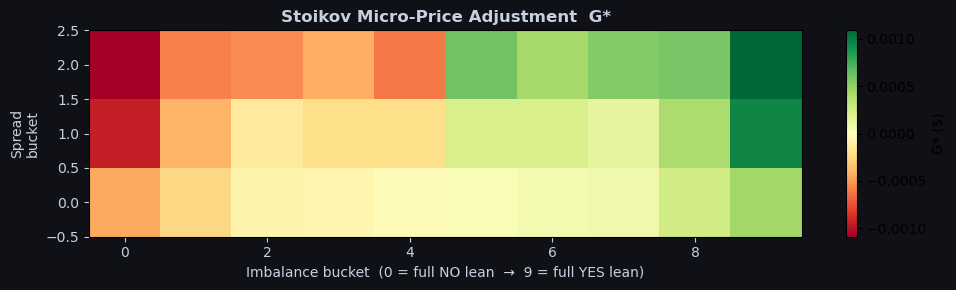

Expected: smooth gradient — red (left/NO-lean) → green (right/YES-lean).
Flat or noisy = lower MP_MIN_COUNT or pool more sessions.


In [ ]:
# G* heatmap — inline render
if train_tickers and Path(GSTAR_PATH).exists():
    grid = np.zeros((MP_MAX_SPREAD, MP_N_IMB))
    for s in range(MP_MAX_SPREAD):
        for i in range(MP_N_IMB):
            grid[s, i] = G_star[i + s * MP_N_IMB]

    BG, TEXT = '#0f1117', '#c8d0e0'
    fig, ax = plt.subplots(figsize=(10, 3), facecolor=BG)
    ax.set_facecolor(BG)
    vmax = np.abs(grid).max() or 0.005
    im = ax.imshow(grid, aspect='auto', origin='lower',
                   cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, label='G* ($)')
    ax.set_xlabel('Imbalance bucket  (0 = full NO lean  →  9 = full YES lean)', color=TEXT)
    ax.set_ylabel('Spread\nbucket', color=TEXT)
    ax.set_title('Stoikov Micro-Price Adjustment  G*', color=TEXT, fontweight='bold')
    ax.tick_params(colors=TEXT)
    plt.tight_layout()
    plt.show()
    print('Expected: smooth gradient — red (left/NO-lean) → green (right/YES-lean).')
    print('Flat or noisy = lower MP_MIN_COUNT or pool more sessions.')

## Inject Micro-Price into Session DataFrames

Loads `g_star.json` and attaches a `microprice` column using a fast vectorised
lookup — no per-row Python loop.

In [ ]:
# load_gstar is defined here so it works whether or not cal is pre-loaded
def load_gstar(path: str) -> dict | None:
    p = Path(path)
    if not p.exists():
        print(f'[G*] {path} not found — run calibration cell first.')
        return None
    cal = json.loads(p.read_text())
    print(f'[G*] loaded  n_imb={cal["n_imb"]}  max_spread={cal["max_spread"]}')
    return cal


# add_microprice is now imported from calibrate_microprice (vectorised, no per-row loop)
add_microprice = calibrate_microprice.add_microprice


cal = load_gstar(GSTAR_PATH)

if cal is not None and not all_data.empty:
    all_data = add_microprice(all_data, cal)
    merged   = add_microprice(merged, cal)

    dev = (all_data['microprice'] - all_data['mid']).dropna()
    print(f'\nDeviation stats across all sessions:')
    print(f'  mean={dev.mean():+.6f}  std={dev.std():.6f}')
    print(f'  min={dev.min():+.6f}   max={dev.max():+.6f}')
    print(f'  |dev| >= {MP_THRESHOLD}: {(dev.abs() >= MP_THRESHOLD).mean():.1%} of ticks')


AttributeError: module 'calibrate_microprice' has no attribute 'add_microprice'

## Micro-Price Signal Test — Single Session

Runs `run_microprice_test()` on the focused session and plots
microprice deviation vs the mid price.

In [ ]:
importlib.reload(obi_signal_test)

if cal is not None and 'microprice' in merged.columns:
    mp_results = obi_signal_test.run_microprice_test(
        merged,
        horizon   = HORIZON,
        threshold = MP_THRESHOLD,
        min_tick  = MIN_TICK,
        cooldown  = COOLDOWN,
    )
    mp_params = dict(threshold=MP_THRESHOLD, horizon=HORIZON,
                     min_tick=MIN_TICK, cooldown=COOLDOWN)
    print(obi_signal_test.summarise_microprice(mp_results, mp_params))
else:
    print('[Skip] microprice column not available — run calibration + inject cells first.')
    mp_results = pd.DataFrame()

No microprice signals fired. Try lowering --threshold.



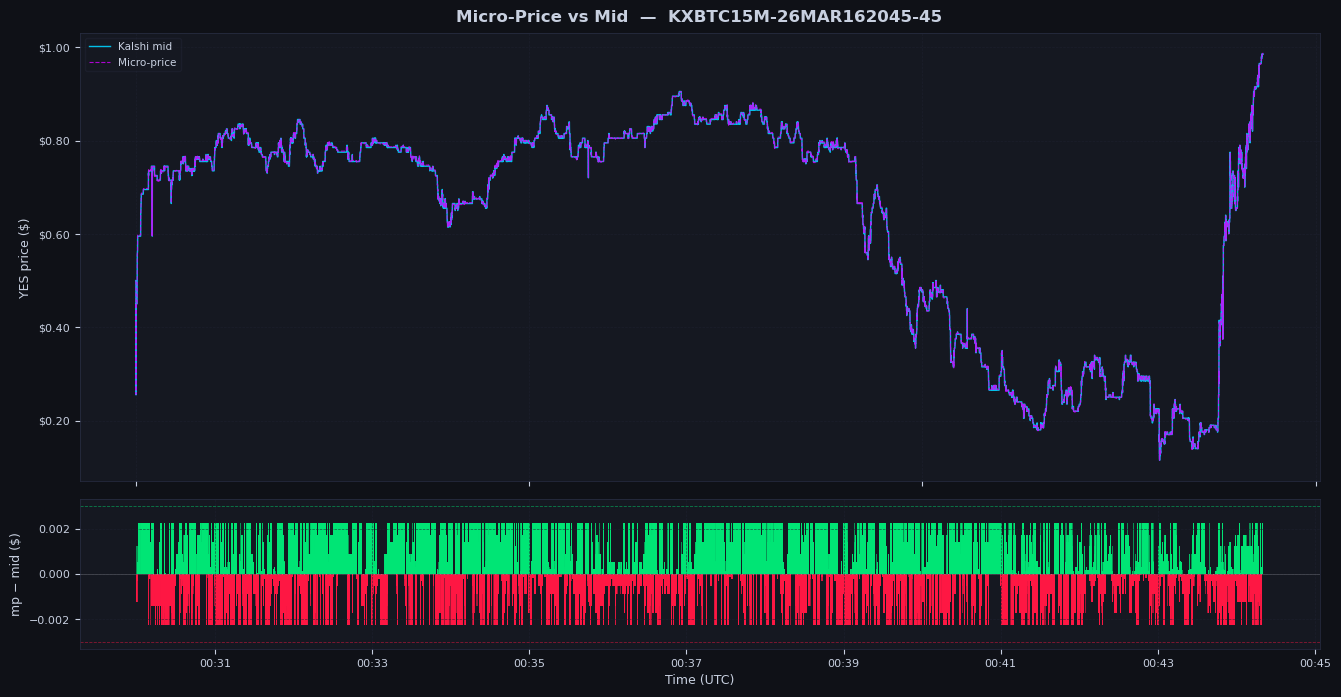

Saved to microprice_KXBTC15M-26MAR162045-45.png


In [ ]:
if cal is not None and 'microprice' in merged.columns:
    BG, AX_BG         = '#0f1117', '#151821'
    GRID, TEXT, SPINE = '#1e2130', '#c8d0e0', '#2a2f45'
    BLUE, PURPLE       = '#00d4ff', '#d400ff'
    GREEN, RED         = '#00e676', '#ff1744'

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), facecolor=BG,
                             gridspec_kw=dict(hspace=0.06, height_ratios=[3, 1]))
    ax_price, ax_dev = axes
    for ax in axes:
        ax.set_facecolor(AX_BG)
        ax.tick_params(colors=TEXT, labelsize=8)
        ax.grid(True, color=GRID, lw=0.5, ls='--', alpha=0.7)
        for sp in ax.spines.values():
            sp.set_color(SPINE); sp.set_linewidth(0.5)

    # Panel 1: mid + microprice + signal markers
    mid = merged['mid'].dropna()
    mp  = merged['microprice'].dropna()
    ax_price.plot(mid.index, mid.values, color=BLUE,   lw=1.0, label='Kalshi mid',  alpha=0.9)
    ax_price.plot(mp.index,  mp.values,  color=PURPLE, lw=0.8, label='Micro-price', alpha=0.8, ls='--')

    if not mp_results.empty:
        hits    = mp_results[mp_results['hit']]
        adverse = mp_results[mp_results['adverse']]
        misses  = mp_results[~mp_results['hit'] & ~mp_results['adverse']]
        if len(hits):    ax_price.scatter(hits.index,    hits['mid_at'],    c=GREEN,   marker='^', s=40, zorder=5, label=f'Hit (n={len(hits)})',      linewidths=0)
        if len(adverse): ax_price.scatter(adverse.index, adverse['mid_at'], c=RED,     marker='v', s=40, zorder=5, label=f'Adverse (n={len(adverse)})', linewidths=0)
        if len(misses):  ax_price.scatter(misses.index,  misses['mid_at'],  c='#ffd600', marker='o', s=30, zorder=4, label=f'No-move (n={len(misses)})', linewidths=0)

    ax_price.set_ylabel('YES price ($)', color=TEXT, fontsize=9)
    ax_price.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:.2f}'))
    ax_price.legend(loc='upper left', fontsize=7.5, framealpha=0.3,
                    labelcolor=TEXT, facecolor=AX_BG, edgecolor=SPINE)
    ax_price.set_title(f'Micro-Price vs Mid  —  {TICKER}', color=TEXT,
                       fontsize=12, fontweight='bold', pad=8)
    ax_price.tick_params(labelbottom=False)

    # Panel 2: deviation bars
    dev = (merged['microprice'] - merged['mid']).dropna()
    ax_dev.bar(dev.index, dev.values, width=pd.Timedelta(seconds=0.8),
               color=np.where(dev.values >= 0, GREEN, RED), alpha=0.6, linewidth=0)
    ax_dev.axhline(0,              color='#ffffff', lw=0.4, alpha=0.3)
    ax_dev.axhline( MP_THRESHOLD,  color=GREEN,     lw=0.6, alpha=0.5, ls='--')
    ax_dev.axhline(-MP_THRESHOLD,  color=RED,       lw=0.6, alpha=0.5, ls='--')
    ax_dev.set_ylabel('mp − mid ($)', color=TEXT, fontsize=9)
    ax_dev.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=timezone.utc))
    ax_dev.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
    plt.setp(ax_dev.xaxis.get_majorticklabels(), rotation=0, ha='center', color=TEXT, fontsize=8)
    ax_dev.set_xlabel('Time (UTC)', color=TEXT, fontsize=9)

    out = f'microprice_{TICKER}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'Saved to {out}')

## Head-to-Head Comparison — OBI Delta vs Micro-Price

Runs both methods on every **held-out test session** and compares hit rates.
This is the key experiment result — if micro-price win rate is materially
higher at the same number of signals, the Stoikov calibration is adding
information beyond raw OBI.

In [ ]:
if cal is None:
    print('[Skip] Load calibration first.')
elif not test_tickers:
    print('[Skip] No held-out test sessions — need at least 2 sessions total.')
else:
    comparison_rows = []

    for ticker_name in test_tickers:
        grp = add_microprice(all_data[all_data['ticker'] == ticker_name].copy(), cal)

        obi_res = obi_signal_test.run_test(
            grp, obi_col='obi',
            horizon=HORIZON, signal_win=SIGNAL_WIN,
            threshold=THRESHOLD, min_tick=MIN_TICK, cooldown=COOLDOWN)

        mp_res = obi_signal_test.run_microprice_test(
            grp, horizon=HORIZON, threshold=MP_THRESHOLD,
            min_tick=MIN_TICK, cooldown=COOLDOWN)

        def _s(res):
            if res.empty:
                return dict(n=0, hit_rate=None, adverse_rate=None, avg_fwd=None)
            return dict(
                n            = len(res),
                hit_rate     = round(res['hit'].mean(), 4),
                adverse_rate = round(res['adverse'].mean(), 4),
                avg_fwd      = round(res['fwd_move'].mean(), 5),
            )

        o, m = _s(obi_res), _s(mp_res)
        comparison_rows.append({
            'ticker'       : ticker_name,
            'obi_n'        : o['n'],
            'obi_hit_rate' : o['hit_rate'],
            'obi_adv_rate' : o['adverse_rate'],
            'obi_avg_fwd'  : o['avg_fwd'],
            'mp_n'         : m['n'],
            'mp_hit_rate'  : m['hit_rate'],
            'mp_adv_rate'  : m['adverse_rate'],
            'mp_avg_fwd'   : m['avg_fwd'],
        })

    cmp_df = pd.DataFrame(comparison_rows).set_index('ticker')
    display(cmp_df)

    print('\n── Aggregate over test sessions ──────────────────────────')
    for method, pfx in [('OBI delta', 'obi'), ('Micro-price', 'mp')]:
        n   = int(cmp_df[f'{pfx}_n'].sum())
        # Guard: skip aggregate stats if no signals fired for this method
        valid = cmp_df[f'{pfx}_hit_rate'].dropna()
        if valid.empty:
            print(f'  {method:<14} n={n:>5}  (no signals fired)')
            continue
        hr  = valid.mean()
        ar  = cmp_df[f'{pfx}_adv_rate'].dropna().mean()
        fwd = cmp_df[f'{pfx}_avg_fwd'].dropna().mean()
        print(f'  {method:<14} n={n:>5}  hit={hr:.1%}  adverse={ar:.1%}  avg_fwd={fwd:+.5f}')


In [ ]:
if 'cmp_df' in dir() and not cmp_df.empty:
    BG, TEXT     = '#0f1117', '#c8d0e0'
    BLUE, PURPLE = '#00d4ff', '#d400ff'
    GREEN        = '#00e676'

    fig, ax = plt.subplots(figsize=(max(8, len(cmp_df) * 1.2), 4), facecolor=BG)
    ax.set_facecolor('#151821')

    x     = np.arange(len(cmp_df))
    width = 0.35

    # Cast to float first so fillna works without the FutureWarning
    obi_rates = cmp_df['obi_hit_rate'].astype(float).fillna(0.0)
    mp_rates  = cmp_df['mp_hit_rate'].astype(float).fillna(0.0)

    ax.bar(x - width/2, obi_rates, width, label='OBI delta',   color=BLUE,   alpha=0.8)
    ax.bar(x + width/2, mp_rates,  width, label='Micro-price', color=PURPLE, alpha=0.8)
    ax.axhline(0.5, color=GREEN, lw=0.8, ls='--', alpha=0.5, label='50% baseline')

    ax.set_xticks(x)
    ax.set_xticklabels([t.split('-', 1)[-1] for t in cmp_df.index],
                       rotation=35, ha='right', color=TEXT, fontsize=7)
    ax.set_ylabel('Hit rate', color=TEXT)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.tick_params(colors=TEXT)
    for sp in ax.spines.values():
        sp.set_color('#2a2f45'); sp.set_linewidth(0.5)
    ax.legend(fontsize=8, framealpha=0.3, labelcolor=TEXT,
              facecolor='#151821', edgecolor='#2a2f45')
    ax.set_title('OBI Delta vs Micro-Price — Hit Rate on Held-Out Test Sessions',
                 color=TEXT, fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig('hitrate_comparison.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()


## Micro-Price Threshold Sweep

Sweeps `MP_THRESHOLD` to find the precision/recall tradeoff:
tighter threshold → fewer but higher-confidence signals.
Run on all sessions (not just test) since this is parameter exploration.

In [ ]:
if cal is not None and not all_data.empty:
    thresholds = [0.001, 0.002, 0.003, 0.005, 0.007, 0.010]
    sweep_rows = []
    sweep_data = add_microprice(all_data.copy(), cal)


    sweep_data = sweep_data.sort_index()

    for thr in thresholds:
        res = obi_signal_test.run_microprice_test(
            sweep_data,
            horizon=HORIZON, threshold=thr,
            min_tick=MIN_TICK, cooldown=COOLDOWN)
        row = {
            'threshold'    : thr,
            'n_signals'    : len(res),
            'hit_rate'     : round(res['hit'].mean(), 4)     if not res.empty else 0.0,
            'adverse_rate' : round(res['adverse'].mean(), 4) if not res.empty else 0.0,
            'avg_fwd_move' : round(res['fwd_move'].mean(), 5) if not res.empty else 0.0,
        }
        sweep_rows.append(row)
        hr_str = f'{res["hit"].mean():.1%}' if not res.empty else 'n/a'
        print(f'threshold={thr:.3f}  n={len(res):>5}  hit={hr_str}')

    display(pd.DataFrame(sweep_rows))
else:
    print('[Skip] Calibration or all_data not available.')

threshold=0.001  n=11316  hit=34.6%
threshold=0.002  n= 9004  hit=36.6%
threshold=0.003  n=    0  hit=n/a
threshold=0.005  n=    0  hit=n/a
threshold=0.007  n=    0  hit=n/a
threshold=0.010  n=    0  hit=n/a


,threshold,n_signals,hit_rate,adverse_rate,avg_fwd_move
0,0.001,11316,0.3464,0.1022,0.00225
1,0.002,9004,0.3663,0.0913,0.00238
2,0.003,0,0.0000,0.0000,0.00000
3,0.005,0,0.0000,0.0000,0.00000
4,0.007,0,0.0000,0.0000,0.00000
5,0.010,0,0.0000,0.0000,0.00000
